In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import nnls
import sys      
from sklearn.model_selection import train_test_split


In [2]:
X_train_rough = np.load('data/X_train_rough.npy')
X_train_np = np.load('data/X_train_np.npy')
y_train_np = np.load('data/y_train_np.npy')
labels_list = np.load('data/labels_list.npy', allow_pickle=True)


In [3]:
plt.ioff()
wavelengths = np.linspace(1550, 1565, 1500)

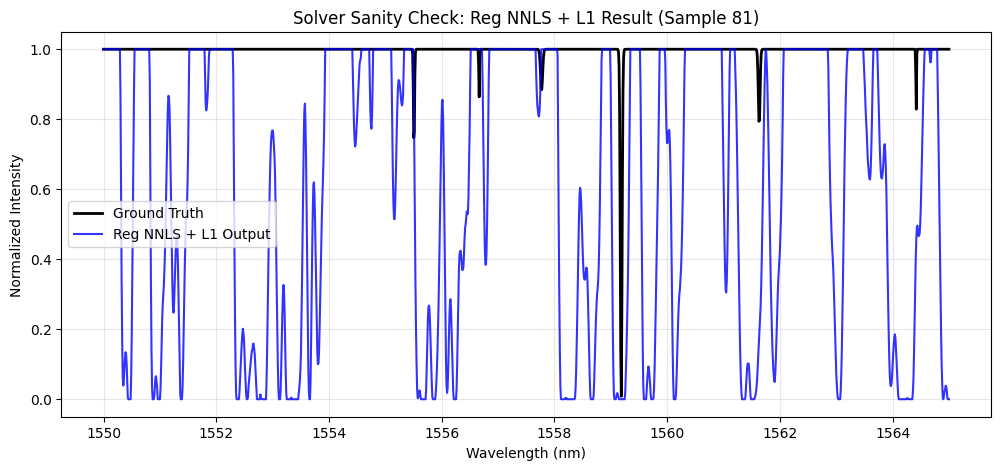

In [4]:
# plot one graph to see
sample_idx = 81
plt.figure(figsize=(12, 5))
plt.plot(wavelengths, y_train_np[sample_idx], label="Ground Truth", color="black", linewidth=2)
plt.plot(wavelengths, X_train_rough[sample_idx], label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=True)



In [5]:
# add classification network

class ClasificationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(25, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 2)

        # activation functions
        self.ReLU = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return x



In [6]:
classificationModel = ClasificationNetwork()
classificationModel.load_state_dict(torch.load('data/classification_model.pth'))
classificationModel.eval()


ClasificationNetwork(
  (layer1): Linear(in_features=25, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=2, bias=True)
  (ReLU): ReLU()
)

In [7]:
# Calculate and save normalization statistics
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)

# Save these for later use
np.save('data/normalization_mean.npy', mean)
np.save('data/normalization_std.npy', std)

print(f"Mean shape: {mean.shape}")
print(f"Std shape: {std.shape}")

Mean shape: (25,)
Std shape: (25,)


In [8]:
# Load normalization statistics
mean = np.load('data/normalization_mean.npy')
std = np.load('data/normalization_std.npy')

# Get multiple samples
samples = X_train_np[:10]  # First 10 samples

# Normalize the samples using the SAME mean and std as training
samples_normalized = (samples - mean) / std

# Convert to tensor
samples_tensor = torch.from_numpy(samples_normalized).float()  # Shape: (10, 25)

# Make predictions
with torch.no_grad():
    outputs = classificationModel(samples_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)


print(f"Predicted classes: {predicted_classes.numpy()}")
# [prob of 0, prob of 1]
print(f"Probabilities:\n{probabilities}")
print(labels_list[:10])


Predicted classes: [0 0 1 1 1 1 0 0 1 0]
Probabilities:
tensor([[9.9564e-01, 4.3559e-03],
        [9.9292e-01, 7.0766e-03],
        [8.3823e-04, 9.9916e-01],
        [1.1855e-06, 1.0000e+00],
        [6.1269e-05, 9.9994e-01],
        [1.4914e-06, 1.0000e+00],
        [9.9465e-01, 5.3537e-03],
        [9.9437e-01, 5.6274e-03],
        [2.4670e-06, 1.0000e+00],
        [9.9311e-01, 6.8909e-03]])
['generate_sparse_spectrum' 'generate_sparse_spectrum'
 'generate_broad_emission' 'generate_broad_absorption'
 'generate_broad_absorption' 'generate_broad_emission'
 'generate_narrow_absorption' 'generate_sparse_spectrum'
 'generate_broad_emission' 'generate_sparse_spectrum']


In [9]:
# Network for broad


# subset data for just broad
broad_types = ["generate_broad_emission", "generate_broad_absorption"]

broad_mask = np.array([label in broad_types for label in labels_list])

# inputs: rough broad spectrums
X_broad_rough = X_train_rough[broad_mask]
# validation broad truth
y_broad_true = y_train_np[broad_mask]

print(f"Total broad samples: {len(X_broad_rough)}")
print(f"Input shape: {X_broad_rough.shape}")
print(f"Target shape: {y_broad_true.shape}")


Total broad samples: 1479
Input shape: (1479, 1500)
Target shape: (1479, 1500)


In [10]:
# split into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X_broad_rough, y_broad_true,
    test_size=0.2,
    random_state=42
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Training: 1183 samples
Test: 296 samples


In [11]:
# Make dataset viable for PyTorch

class BroadSpectrumDataset(Dataset):
    # convert to tensors
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    # so that batches can be created
    def __len__(self):
        return len(self.X)

    # called during training when creating data
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BroadSpectrumDataset(X_train, y_train)
# feed batch_size input target pairs at once and shuffle
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Number of batches: {len(train_loader)}")


Number of batches: 37


In [12]:
# Broad Network

class BroadSolverNetwork(nn.Module):
    def __init__(self):
        super().__init__()
    
        self.layer1 = nn.Linear(1500, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)

        self.ReLU = nn.ReLU()
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return x





In [13]:
# # loss function

# def broad_loss(predicted, target, smoothness_lambda = 0.1):

#     # how close
#     mse = nn.MSELoss()(predicted, target)

#     # how smooth, penalize big jumps
#     smoothness = torch.mean((predicted[:, 1:] - predicted[:, :-1]) ** 2)

#     return mse + smoothness_lambda * smoothness

In [14]:
def broad_loss(pred, target, smoothness_lambda=0.1, amp_alpha=2.0):
    weight = 1.0 + amp_alpha * target
    recon = torch.mean(weight * (pred - target) ** 2)
    smooth = torch.mean((pred[:, 1:] - pred[:, :-1]) ** 2)
    return recon + smoothness_lambda * smooth


In [15]:
model = BroadSolverNetwork()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        predicted = model(batch_X)

        loss = broad_loss(predicted, batch_y)

        # backward pass
        optimizer.zero_grad()
        loss.backward()

        # update the weights
        optimizer.step()

        epoch_loss += loss.item()


    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 10/200, Loss: 0.015853
Epoch 20/200, Loss: 0.013400
Epoch 30/200, Loss: 0.009353
Epoch 40/200, Loss: 0.007914
Epoch 50/200, Loss: 0.007326
Epoch 60/200, Loss: 0.005977
Epoch 70/200, Loss: 0.005734
Epoch 80/200, Loss: 0.005113
Epoch 90/200, Loss: 0.004511
Epoch 100/200, Loss: 0.003977
Epoch 110/200, Loss: 0.004075
Epoch 120/200, Loss: 0.003542
Epoch 130/200, Loss: 0.003358
Epoch 140/200, Loss: 0.003415
Epoch 150/200, Loss: 0.002727
Epoch 160/200, Loss: 0.002962
Epoch 170/200, Loss: 0.002131
Epoch 180/200, Loss: 0.002174
Epoch 190/200, Loss: 0.003335
Epoch 200/200, Loss: 0.001839


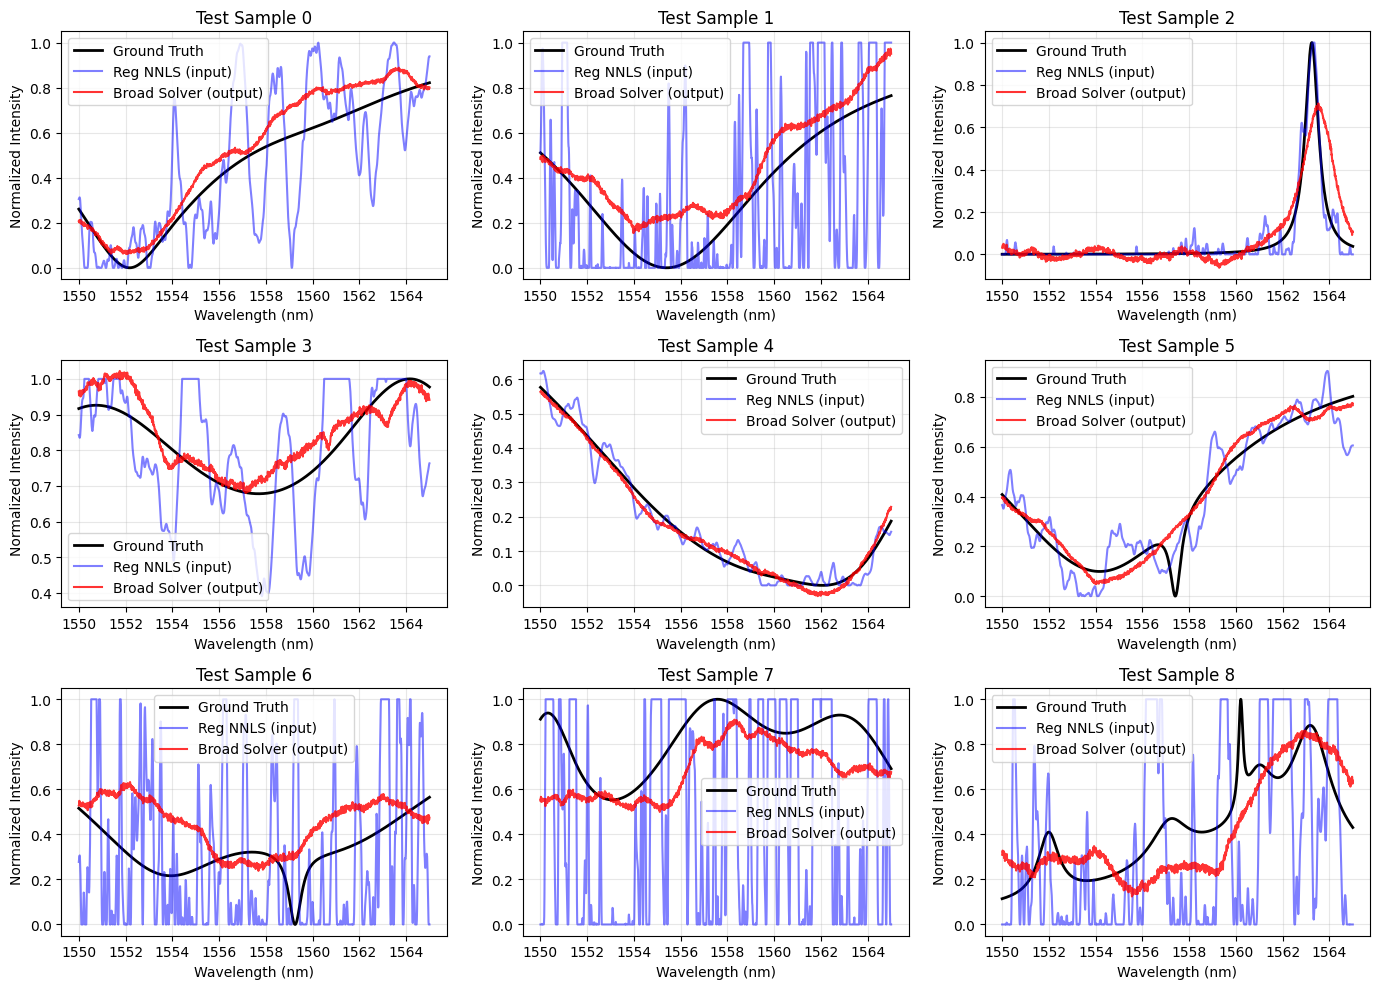

<Figure size 640x480 with 0 Axes>

In [16]:
model.eval()

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# Plot a few examples
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i in range(9):
    ax = axes[i]
    ax.plot(wavelengths, y_test[i], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[i], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions[i], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {i}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("broadoutput.png")

In [17]:
mse_before = np.mean((X_test - y_test) ** 2)
mse_after = np.mean((predictions - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after (Broad Solver): {mse_after:.6f}")
print(f"Improvement: {((mse_before - mse_after) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after (Broad Solver): 0.010431
Improvement: 86.0%


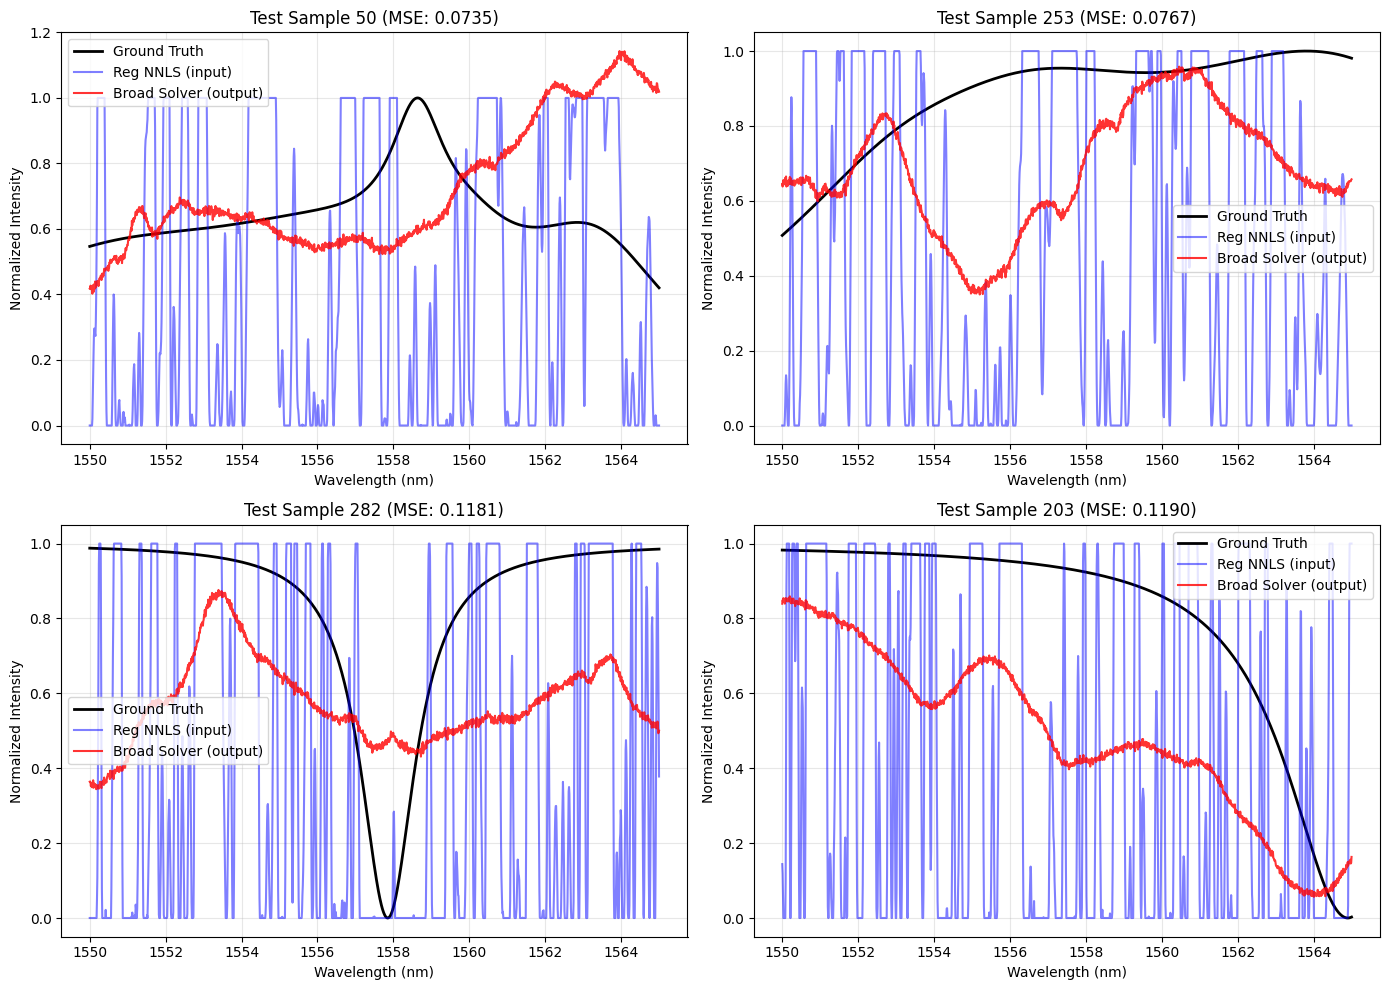

<Figure size 640x480 with 0 Axes>

In [18]:
sample_mse = np.mean((predictions - y_test) ** 2, axis=1)
worst_indices = np.argsort(sample_mse)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(worst_indices):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions[idx], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("firstWorstOutputs.png")

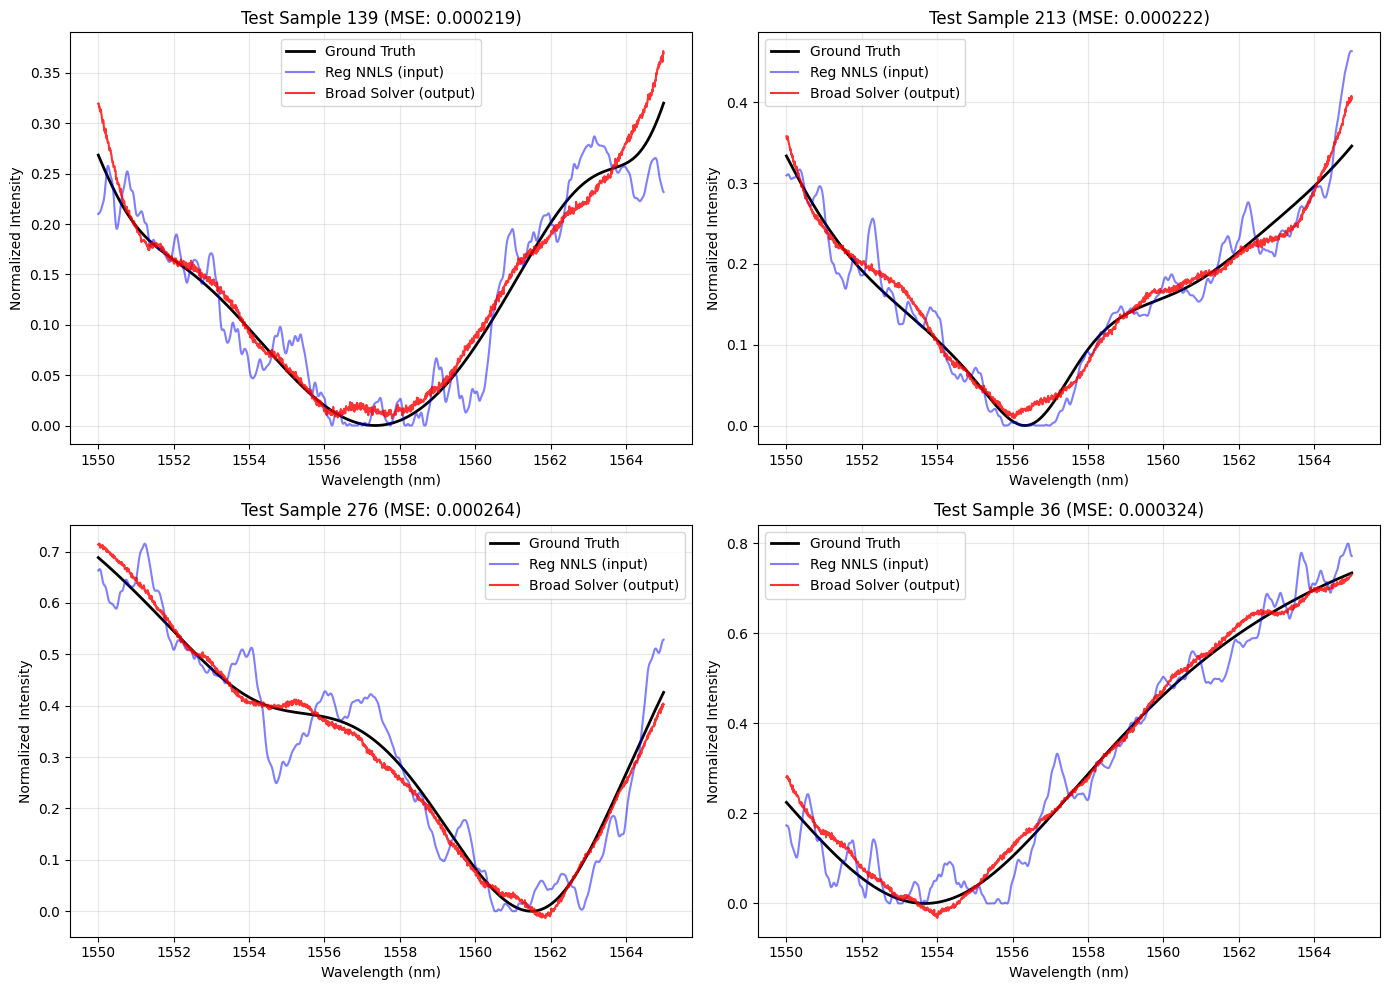

<Figure size 640x480 with 0 Axes>

In [19]:
sample_mse = np.mean((predictions - y_test) ** 2, axis=1)
best_indices = np.argsort(sample_mse)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(best_indices):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions[idx], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse[idx]:.6f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("firstBestOutput.png")

In [20]:
# Second Attempt
# Broad Network

class BroadSolverNetworkv2(nn.Module):
    def __init__(self):
        super().__init__()
    
        self.layer1 = nn.Linear(1500, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)

        self.ReLU = nn.ReLU()
    
    def forward(self, x):
        residual = x
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return residual + x





In [21]:
model_v2 = BroadSolverNetworkv2()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model_v2.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        predicted = model_v2(batch_X)

        loss = broad_loss(predicted, batch_y)

        # backward pass
        optimizer_v2.zero_grad()
        loss.backward()

        # update the weights
        optimizer_v2.step()

        epoch_loss += loss.item()


    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 10/200, Loss: 0.040598
Epoch 20/200, Loss: 0.025803
Epoch 30/200, Loss: 0.020402
Epoch 40/200, Loss: 0.016335
Epoch 50/200, Loss: 0.014743
Epoch 60/200, Loss: 0.014020
Epoch 70/200, Loss: 0.012726
Epoch 80/200, Loss: 0.012974
Epoch 90/200, Loss: 0.011864
Epoch 100/200, Loss: 0.011480
Epoch 110/200, Loss: 0.011125
Epoch 120/200, Loss: 0.011299
Epoch 130/200, Loss: 0.010136
Epoch 140/200, Loss: 0.010496
Epoch 150/200, Loss: 0.009979
Epoch 160/200, Loss: 0.010722
Epoch 170/200, Loss: 0.010607
Epoch 180/200, Loss: 0.009866
Epoch 190/200, Loss: 0.009531
Epoch 200/200, Loss: 0.009523


In [22]:
model_v2.eval()

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    predictions_v2 = model_v2(X_test_tensor).numpy()

mse_before = np.mean((X_test - y_test) ** 2)
mse_after_v2 = np.mean((predictions_v2 - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after (Broad Solver V2): {mse_after_v2:.6f}")
print(f"Improvement: {((mse_before - mse_after_v2) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after (Broad Solver V2): 0.023954
Improvement: 67.8%


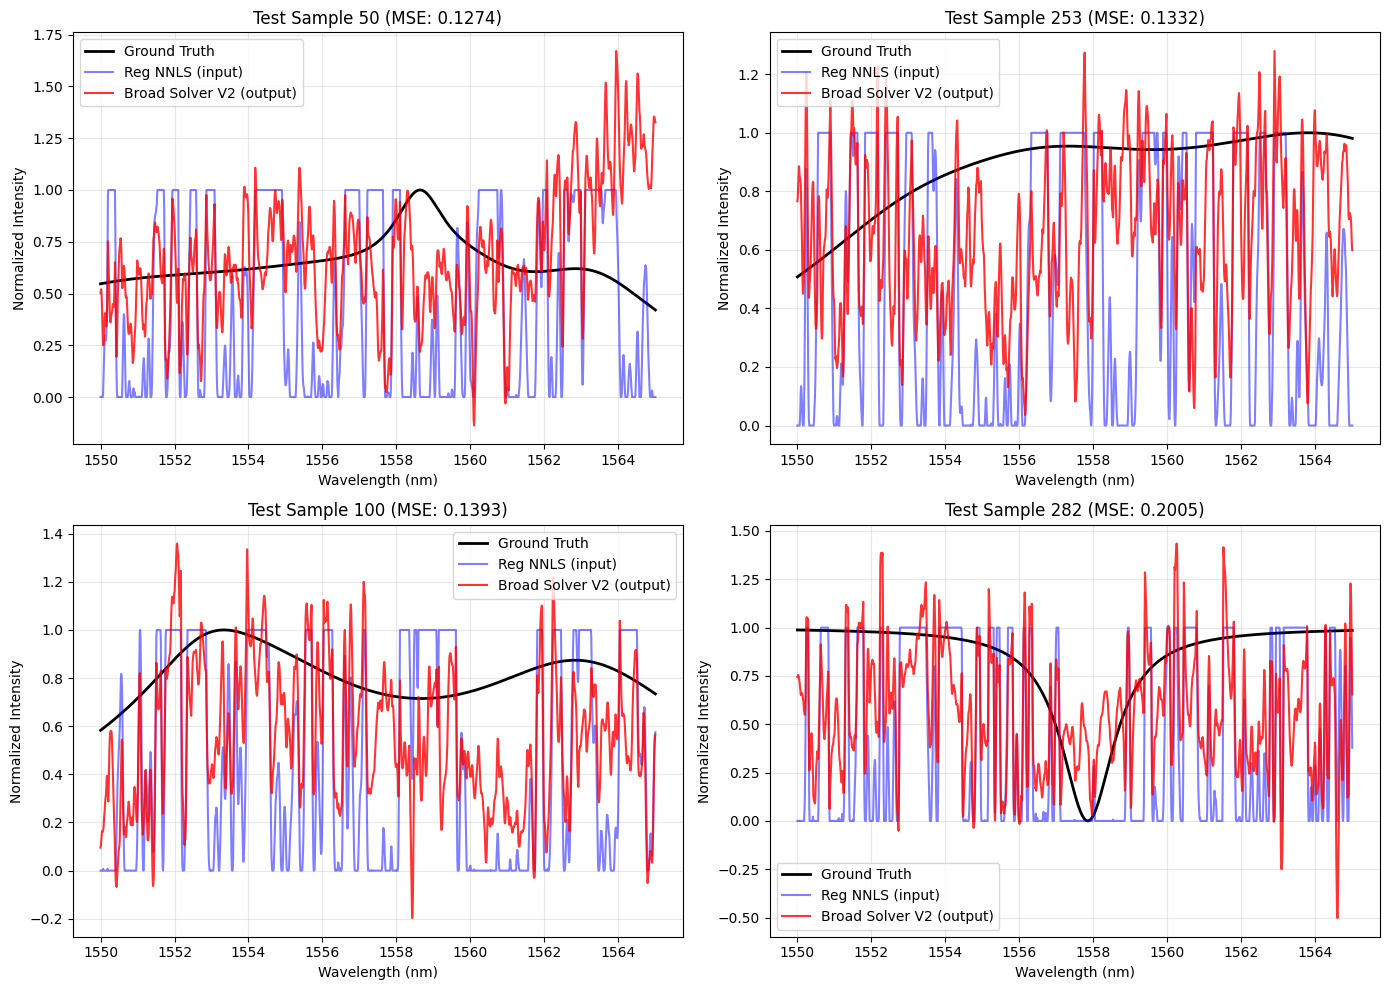

In [23]:
sample_mse_v2 = np.mean((predictions_v2 - y_test) ** 2, axis=1)
worst_indices_v2 = np.argsort(sample_mse_v2)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(worst_indices_v2):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v2[idx], label="Broad Solver V2 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v2[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

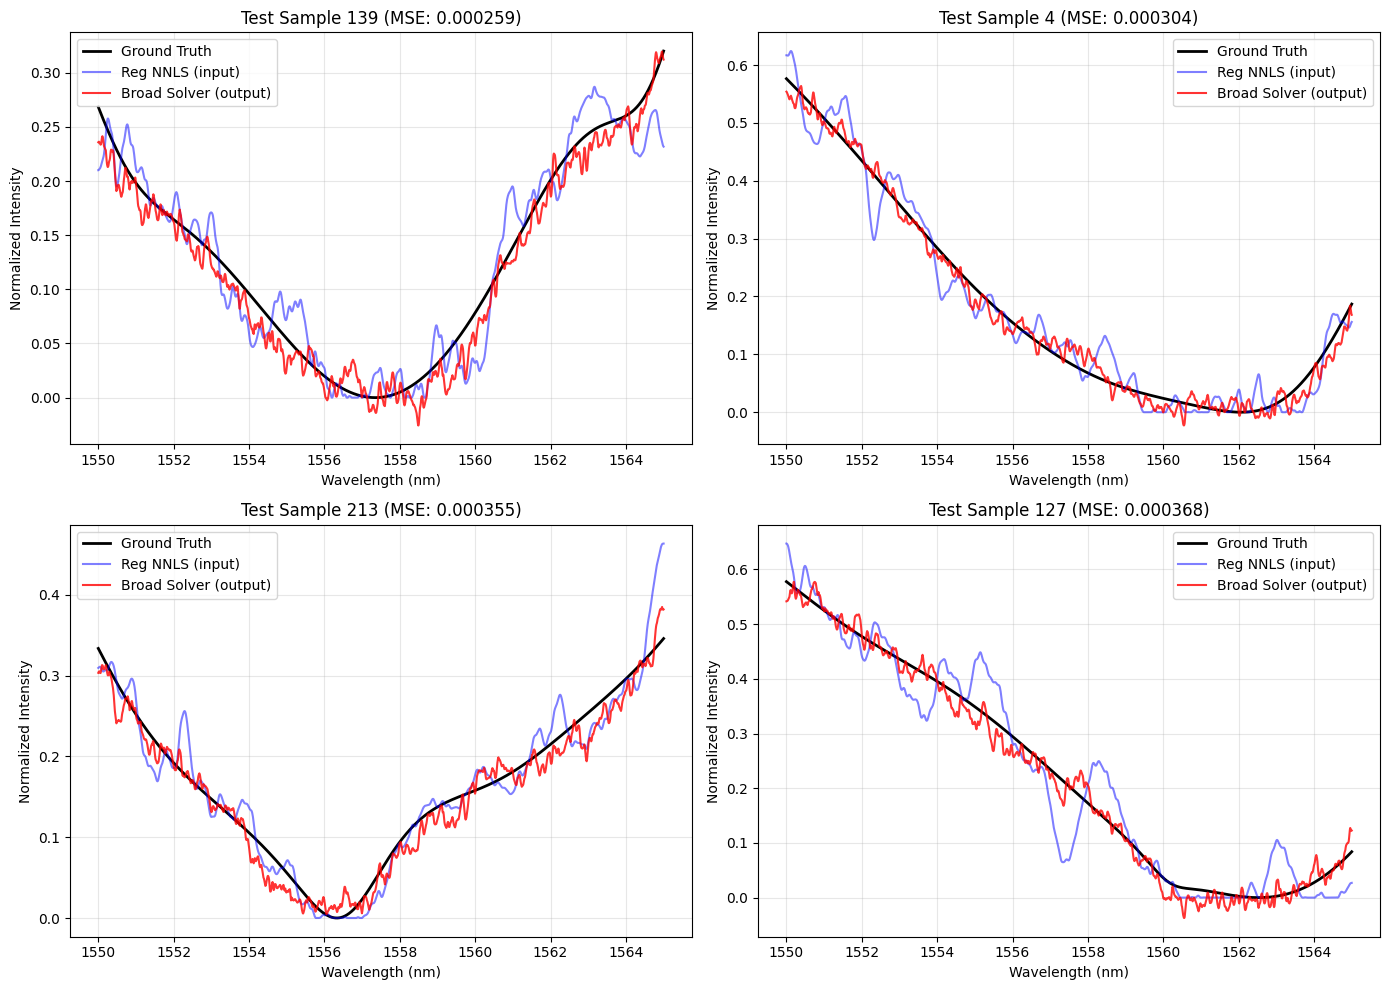

<Figure size 640x480 with 0 Axes>

In [24]:
sample_mse = np.mean((predictions_v2 - y_test) ** 2, axis=1)
best_indices = np.argsort(sample_mse_v2)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(best_indices):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v2[idx], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v2[idx]:.6f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("firstBestOutput.png")

In [25]:
class BroadSolverNetworkV3(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer1 = nn.Linear(1500, 2048)
        self.layer2 = nn.Linear(2048, 1024)
        self.layer3 = nn.Linear(1024, 1500)
        
        self.ReLU = nn.ReLU()
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)
        
        x = self.layer2(x)
        x = self.ReLU(x)
        
        x = self.layer3(x)
        
        return x

In [26]:
model_v3 = BroadSolverNetworkV3()
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model_v3.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        predicted = model_v3(batch_X)

        loss = broad_loss(predicted, batch_y)

        # backward pass
        optimizer_v3.zero_grad()
        loss.backward()

        # update the weights
        optimizer_v3.step()

        epoch_loss += loss.item()


    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 10/200, Loss: 0.016003
Epoch 20/200, Loss: 0.010716
Epoch 30/200, Loss: 0.007650
Epoch 40/200, Loss: 0.006192
Epoch 50/200, Loss: 0.006013
Epoch 60/200, Loss: 0.005881
Epoch 70/200, Loss: 0.007119
Epoch 80/200, Loss: 0.004150
Epoch 90/200, Loss: 0.003852
Epoch 100/200, Loss: 0.004297
Epoch 110/200, Loss: 0.002830
Epoch 120/200, Loss: 0.003397
Epoch 130/200, Loss: 0.002766
Epoch 140/200, Loss: 0.002455
Epoch 150/200, Loss: 0.002731
Epoch 160/200, Loss: 0.003381
Epoch 170/200, Loss: 0.001955
Epoch 180/200, Loss: 0.002149
Epoch 190/200, Loss: 0.001535
Epoch 200/200, Loss: 0.002674


In [27]:
model_v3.eval()

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    predictions_v3 = model_v3(X_test_tensor).numpy()

mse_after_v3 = np.mean((predictions_v3 - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after V1 (original): 0.010952")
print(f"MSE after V3 (wider): {mse_after_v3:.6f}")
print(f"V3 Improvement over Reg NNLS: {((mse_before - mse_after_v3) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after V1 (original): 0.010952
MSE after V3 (wider): 0.010794
V3 Improvement over Reg NNLS: 85.5%


In [28]:
X_broad_raw = X_train_np[broad_mask]
X_raw_train, X_raw_test = train_test_split(
    X_broad_raw, test_size=0.2, random_state=42
)

In [29]:
class BroadSpectrumDatasetV2(Dataset):
    def __init__(self, X_rough, X_raw, y):
        self.X_rough = torch.from_numpy(X_rough).float()
        self.X_raw = torch.from_numpy(X_raw).float()
        self.y = torch.from_numpy(y).float()
    
    def __len__(self):
        return len(self.X_rough)
    
    def __getitem__(self, idx):
        return self.X_rough[idx], self.X_raw[idx], self.y[idx]

mean = np.load('data/normalization_mean.npy')
std = np.load('data/normalization_std.npy')

X_raw_train_norm = (X_raw_train - mean) / std
X_raw_test_norm = (X_raw_test - mean) / std
# print(X_test.shape)
print(X_raw_test_norm.shape)


train_dataset_v2 = BroadSpectrumDatasetV2(X_train, X_raw_train_norm, y_train)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, shuffle=True)


(296, 25)


In [30]:
class BroadSolverNetworkV4(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer1 = nn.Linear(1525, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(1024, 1024)
        self.layer4 = nn.Linear(512, 1500)
        
        self.ReLU = nn.ReLU()
    
    def forward(self, x_rough, x_raw):
        x = torch.cat([x_rough, x_raw], dim=1)
        
        x = self.layer1(x)
        x = self.ReLU(x)
        
        x = self.layer2(x)
        x = self.ReLU(x)
        
        x = self.layer3(x)
        
        return x

In [31]:
model_v4 = BroadSolverNetworkV4()
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=1e-3)

for epoch in range(400):
    model_v4.train()
    epoch_loss = 0.0
    
    for batch_rough, batch_raw, batch_y in train_loader_v2:
        predicted = model_v4(batch_rough, batch_raw)
        loss = broad_loss(predicted, batch_y)
        
        optimizer_v4.zero_grad()
        loss.backward()
        optimizer_v4.step()
        
        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader_v2)
        print(f"Epoch {epoch+1}/200, Loss: {avg_loss:.6f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x512 and 1024x1024)

In [ ]:
print(X_test.shape)
print(X_raw_test_norm.shape)


(296, 1500)
(296, 25)


In [ ]:
model_v4.eval()
X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()


with torch.no_grad():
    predictions_v4 = model_v4(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v4 = np.mean((predictions_v4 - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after V1 (original): 0.010952")
print(f"MSE after V4 (wider): {mse_after_v4:.6f}")
print(f"V3 Improvement over Reg NNLS: {((mse_before - mse_after_v4) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after V1 (original): 0.010952
MSE after V4 (wider): 0.007323
V3 Improvement over Reg NNLS: 90.2%


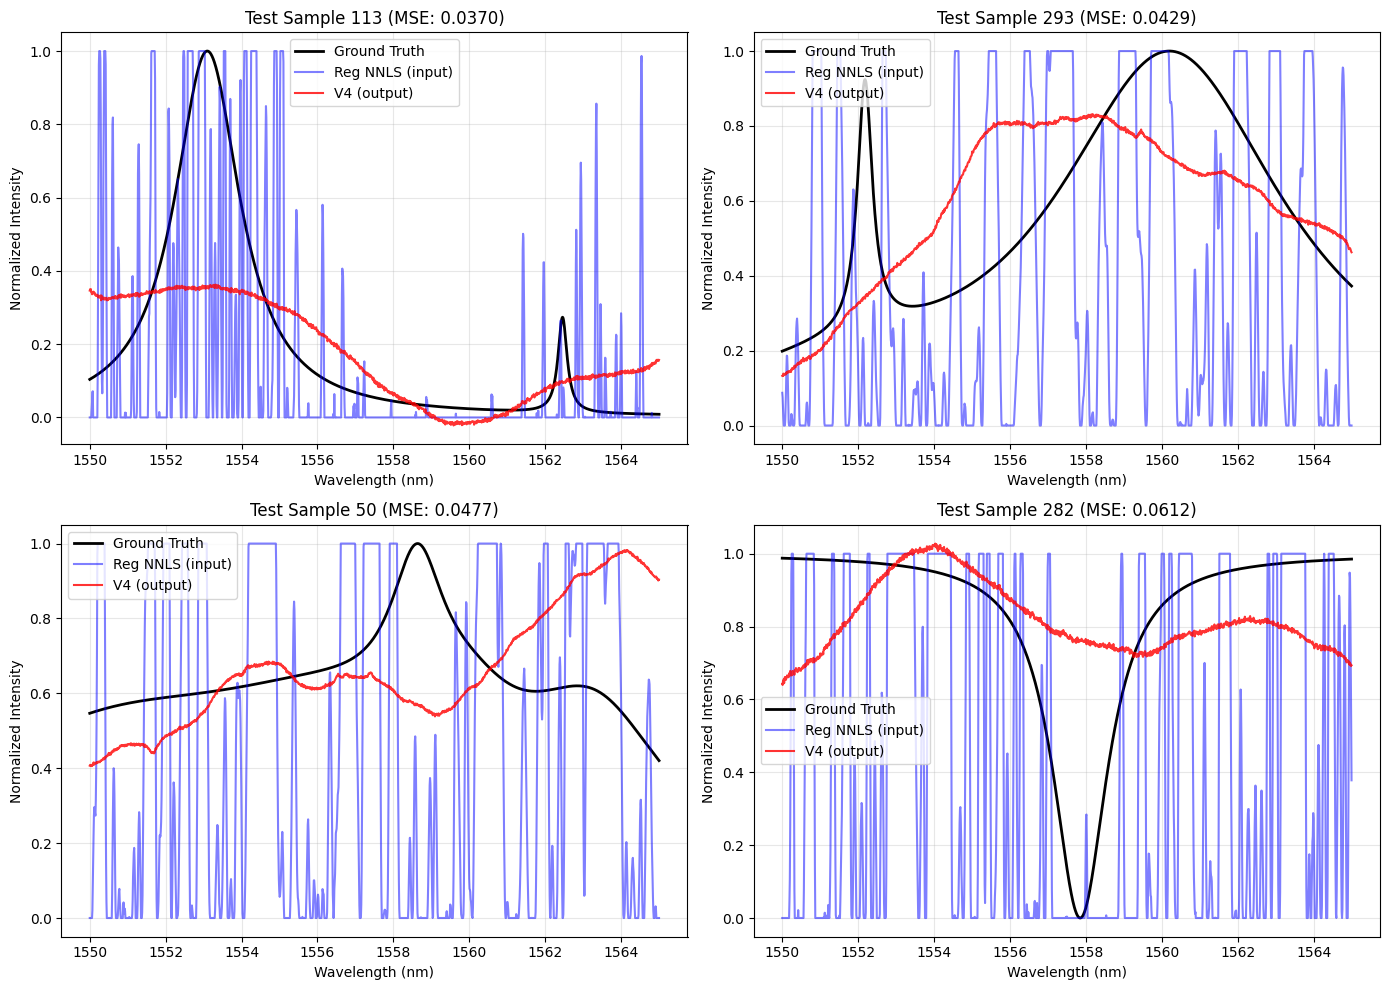

In [ ]:
sample_mse_v4 = np.mean((predictions_v4 - y_test) ** 2, axis=1)
worst_indices_v4 = np.argsort(sample_mse_v4)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(worst_indices_v4):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v4[idx], label="V4 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v4[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# square of mse

In [ ]:
# V5 = clean V4 architecture (1525 -> 1024 -> 512 -> 1500) + cosine annealing LR.
# V4's training loss was still falling at epoch 400 with fixed lr=1e-3, suggesting the
# step size was too coarse for late-stage refinement. Cosine annealing smoothly decays
# lr from 1e-3 toward 0 across all epochs - big steps early, fine adjustments later.

class BroadSolverNetworkV5(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1525, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)
        self.ReLU = nn.ReLU()

    def forward(self, x_rough, x_raw):
        x = torch.cat([x_rough, x_raw], dim=1)
        x = self.ReLU(self.layer1(x))
        x = self.ReLU(self.layer2(x))
        x = self.layer3(x)
        return x


In [ ]:
model_v5 = BroadSolverNetworkV5()
optimizer_v5 = torch.optim.Adam(model_v5.parameters(), lr=1e-3)
num_epochs = 400
scheduler_v5 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v5, T_max=num_epochs)

for epoch in range(num_epochs):
    model_v5.train()
    epoch_loss = 0.0

    for batch_rough, batch_raw, batch_y in train_loader_v2:
        predicted = model_v5(batch_rough, batch_raw)
        loss = broad_loss(predicted, batch_y)

        optimizer_v5.zero_grad()
        loss.backward()
        optimizer_v5.step()

        epoch_loss += loss.item()

    scheduler_v5.step()  # decay learning rate after each epoch

    if (epoch + 1) % 20 == 0:
        avg_loss = epoch_loss / len(train_loader_v2)
        current_lr = scheduler_v5.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.2e}")


In [ ]:
model_v5.eval()
X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()

with torch.no_grad():
    predictions_v5 = model_v5(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v5 = np.mean((predictions_v5 - y_test) ** 2)

print(f"MSE before (Reg NNLS):         {mse_before:.6f}")
print(f"MSE after V4 (no schedule):    0.007323")
print(f"MSE after V5 (cosine LR):      {mse_after_v5:.6f}")
print(f"V5 Improvement over Reg NNLS:  {((mse_before - mse_after_v5) / mse_before) * 100:.1f}%")


In [ ]:
sample_mse_v5 = np.mean((predictions_v5 - y_test) ** 2, axis=1)
worst_indices_v5 = np.argsort(sample_mse_v5)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(worst_indices_v5):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v5[idx], label="V5 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v5[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# V6 = V5 + weight decay (regularization) + validation tracking.
# Two coupled changes:
#   1. Adam -> AdamW with weight_decay=1e-4: penalizes large weights, fights overfitting
#   2. Compute test MSE every 20 epochs: lets us SEE the train/test gap as it forms

model_v6 = BroadSolverNetworkV5()  # same architecture as V5
optimizer_v6 = torch.optim.AdamW(model_v6.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 400
scheduler_v6 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v6, T_max=num_epochs)

# Pre-build test tensors so we evaluate fast each checkpoint
X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_losses_v6 = []
val_mses_v6 = []
epochs_recorded_v6 = []

for epoch in range(num_epochs):
    model_v6.train()
    epoch_loss = 0.0

    for batch_rough, batch_raw, batch_y in train_loader_v2:
        predicted = model_v6(batch_rough, batch_raw)
        loss = broad_loss(predicted, batch_y)

        optimizer_v6.zero_grad()
        loss.backward()
        optimizer_v6.step()

        epoch_loss += loss.item()

    scheduler_v6.step()
    avg_train_loss = epoch_loss / len(train_loader_v2)

    if (epoch + 1) % 20 == 0:
        model_v6.eval()
        with torch.no_grad():
            val_pred = model_v6(X_test_tensor, X_raw_test_norm_tensor)
            val_mse = torch.mean((val_pred - y_test_tensor) ** 2).item()

        train_losses_v6.append(avg_train_loss)
        val_mses_v6.append(val_mse)
        epochs_recorded_v6.append(epoch + 1)
        current_lr = scheduler_v6.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{num_epochs}, Train: {avg_train_loss:.6f}, Test MSE: {val_mse:.6f}, LR: {current_lr:.2e}")


In [ ]:
# Plot the train/test curves on log scale - if there's overfitting, you'll see them diverge
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded_v6, train_losses_v6, label="Train Loss", color="blue", marker='o', markersize=4)
plt.plot(epochs_recorded_v6, val_mses_v6, label="Test MSE", color="red", marker='o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss / MSE")
plt.yscale("log")
plt.title("V6: Train Loss vs Test MSE (log scale)")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

# Identify when test MSE was at its best - tells us if we should have stopped earlier
best_epoch_idx = int(np.argmin(val_mses_v6))
print(f"Best test MSE: {val_mses_v6[best_epoch_idx]:.6f} at epoch {epochs_recorded_v6[best_epoch_idx]}")
print(f"Final test MSE: {val_mses_v6[-1]:.6f} at epoch {epochs_recorded_v6[-1]}")


In [ ]:
model_v6.eval()
with torch.no_grad():
    predictions_v6 = model_v6(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v6 = np.mean((predictions_v6 - y_test) ** 2)

print(f"MSE before (Reg NNLS):              {mse_before:.6f}")
print(f"MSE after V4 (no schedule):         0.007323")
print(f"MSE after V5 (cosine LR):           {mse_after_v5:.6f}")
print(f"MSE after V6 (cosine LR + AdamW):   {mse_after_v6:.6f}")
print(f"V6 Improvement over Reg NNLS:       {((mse_before - mse_after_v6) / mse_before) * 100:.1f}%")

# Worst cases for V6
sample_mse_v6 = np.mean((predictions_v6 - y_test) ** 2, axis=1)
worst_indices_v6 = np.argsort(sample_mse_v6)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, idx in enumerate(worst_indices_v6):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v6[idx], label="V6 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v6[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# V7 = V6 + input noise augmentation.
# Hypothesis: 1183 training samples is the bottleneck. Adding random noise to inputs
# each batch makes every epoch see a "fresh" dataset - effectively unlimited data.
# Targets stay clean so the network learns the noise-invariant mapping.

NOISE_STD_ROUGH = 0.02  # noise on NNLS rough draft (values ~[0, 1] range)
NOISE_STD_RAW = 0.1     # noise on raw measurements (normalized to ~unit variance)

class BroadSpectrumDatasetV3(Dataset):
    def __init__(self, X_rough, X_raw, y, noise_std_rough=NOISE_STD_ROUGH, noise_std_raw=NOISE_STD_RAW):
        self.X_rough = torch.from_numpy(X_rough).float()
        self.X_raw = torch.from_numpy(X_raw).float()
        self.y = torch.from_numpy(y).float()
        self.noise_std_rough = noise_std_rough
        self.noise_std_raw = noise_std_raw

    def __len__(self):
        return len(self.X_rough)

    def __getitem__(self, idx):
        # Fresh noise each access -> every epoch sees a different version of each sample
        rough = self.X_rough[idx] + torch.randn_like(self.X_rough[idx]) * self.noise_std_rough
        raw = self.X_raw[idx] + torch.randn_like(self.X_raw[idx]) * self.noise_std_raw
        return rough, raw, self.y[idx]


train_dataset_v3 = BroadSpectrumDatasetV3(X_train, X_raw_train_norm, y_train)
train_loader_v3 = DataLoader(train_dataset_v3, batch_size=32, shuffle=True)
print(f"V3 dataset: {len(train_dataset_v3)} samples, noise std rough={NOISE_STD_ROUGH}, raw={NOISE_STD_RAW}")


In [ ]:
model_v7 = BroadSolverNetworkV5()  # same arch as V5/V6
optimizer_v7 = torch.optim.AdamW(model_v7.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 400
scheduler_v7 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v7, T_max=num_epochs)

# Test tensors - no noise on test, we want clean evaluation
X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_losses_v7 = []
val_mses_v7 = []
epochs_recorded_v7 = []

for epoch in range(num_epochs):
    model_v7.train()
    epoch_loss = 0.0

    for batch_rough, batch_raw, batch_y in train_loader_v3:  # <-- noisy loader
        predicted = model_v7(batch_rough, batch_raw)
        loss = broad_loss(predicted, batch_y)

        optimizer_v7.zero_grad()
        loss.backward()
        optimizer_v7.step()

        epoch_loss += loss.item()

    scheduler_v7.step()
    avg_train_loss = epoch_loss / len(train_loader_v3)

    if (epoch + 1) % 20 == 0:
        model_v7.eval()
        with torch.no_grad():
            val_pred = model_v7(X_test_tensor, X_raw_test_norm_tensor)
            val_mse = torch.mean((val_pred - y_test_tensor) ** 2).item()

        train_losses_v7.append(avg_train_loss)
        val_mses_v7.append(val_mse)
        epochs_recorded_v7.append(epoch + 1)
        current_lr = scheduler_v7.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{num_epochs}, Train: {avg_train_loss:.6f}, Test MSE: {val_mse:.6f}, LR: {current_lr:.2e}")


In [ ]:
# Plot V7 train/test curves - if augmentation works, the gap should narrow
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded_v7, train_losses_v7, label="Train Loss", color="blue", marker='o', markersize=4)
plt.plot(epochs_recorded_v7, val_mses_v7, label="Test MSE", color="red", marker='o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss / MSE")
plt.yscale("log")
plt.title("V7: Train Loss vs Test MSE (with input noise augmentation)")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

best_epoch_idx = int(np.argmin(val_mses_v7))
print(f"Best test MSE: {val_mses_v7[best_epoch_idx]:.6f} at epoch {epochs_recorded_v7[best_epoch_idx]}")
print(f"Final test MSE: {val_mses_v7[-1]:.6f} at epoch {epochs_recorded_v7[-1]}")


In [ ]:
model_v7.eval()
with torch.no_grad():
    predictions_v7 = model_v7(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v7 = np.mean((predictions_v7 - y_test) ** 2)

print(f"MSE before (Reg NNLS):                  {mse_before:.6f}")
print(f"MSE after V4 (no schedule):             0.007323")
print(f"MSE after V5 (cosine LR):               {mse_after_v5:.6f}")
print(f"MSE after V6 (cosine LR + AdamW):       {mse_after_v6:.6f}")
print(f"MSE after V7 (V6 + input noise aug):    {mse_after_v7:.6f}")
print(f"V7 Improvement over Reg NNLS:           {((mse_before - mse_after_v7) / mse_before) * 100:.1f}%")

# Worst cases for V7
sample_mse_v7 = np.mean((predictions_v7 - y_test) ** 2, axis=1)
worst_indices_v7 = np.argsort(sample_mse_v7)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, idx in enumerate(worst_indices_v7):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v7[idx], label="V7 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v7[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# V8 = V6 setup (cosine LR + AdamW), trained on the original 1183 broad samples
# PLUS 4000 extra broad samples generated with seed=84.
# Test set stays the SAME (296 samples) so V8 MSE is directly comparable to V4-V7.

# Load the extra broad data
X_train_np_extra = np.load("data/X_train_np_broad_extra.npy")
y_train_np_extra = np.load("data/y_train_np_broad_extra.npy")
X_train_rough_extra = np.load("data/X_train_rough_broad_extra_alpha50000.npy")

# Append extra to original training set (test set unchanged)
X_train_v8 = np.concatenate([X_train, X_train_rough_extra], axis=0)
y_train_v8 = np.concatenate([y_train, y_train_np_extra], axis=0)
X_raw_train_v8 = np.concatenate([X_raw_train, X_train_np_extra], axis=0)
X_raw_train_v8_norm = (X_raw_train_v8 - mean) / std

train_dataset_v8 = BroadSpectrumDatasetV2(X_train_v8, X_raw_train_v8_norm, y_train_v8)
train_loader_v8 = DataLoader(train_dataset_v8, batch_size=32, shuffle=True)

print(f"V8 training set: {len(train_dataset_v8)} samples (was 1183, now {len(train_dataset_v8)})")
print(f"V8 test set:     {len(X_test)} samples (unchanged)")
print(f"V8 batches/epoch: {len(train_loader_v8)}")


In [ ]:
model_v8 = BroadSolverNetworkV5()  # same architecture as V5/V6/V7
optimizer_v8 = torch.optim.AdamW(model_v8.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 400
scheduler_v8 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v8, T_max=num_epochs)

# Same test tensors as V6/V7 - identical evaluation
X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_losses_v8 = []
val_mses_v8 = []
epochs_recorded_v8 = []

# Early stopping: keep a snapshot of the model at the lowest test MSE.
# At the end, restore the best snapshot - so model_v8 is the BEST version, not the final one.
best_val_mse = float('inf')
best_state = None
best_epoch_v8 = -1

for epoch in range(num_epochs):
    model_v8.train()
    epoch_loss = 0.0

    for batch_rough, batch_raw, batch_y in train_loader_v8:
        predicted = model_v8(batch_rough, batch_raw)
        loss = broad_loss(predicted, batch_y)

        optimizer_v8.zero_grad()
        loss.backward()
        optimizer_v8.step()

        epoch_loss += loss.item()

    scheduler_v8.step()
    avg_train_loss = epoch_loss / len(train_loader_v8)

    if (epoch + 1) % 20 == 0:
        model_v8.eval()
        with torch.no_grad():
            val_pred = model_v8(X_test_tensor, X_raw_test_norm_tensor)
            val_mse = torch.mean((val_pred - y_test_tensor) ** 2).item()

        # Snapshot model if this is the best test MSE so far
        improved = ""
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.detach().clone() for k, v in model_v8.state_dict().items()}
            best_epoch_v8 = epoch + 1
            improved = "  <-- new best"

        train_losses_v8.append(avg_train_loss)
        val_mses_v8.append(val_mse)
        epochs_recorded_v8.append(epoch + 1)
        current_lr = scheduler_v8.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{num_epochs}, Train: {avg_train_loss:.6f}, Test MSE: {val_mse:.6f}, LR: {current_lr:.2e}{improved}")

# Restore best model so model_v8 is the snapshot from best_epoch_v8
model_v8.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch_v8} (test MSE = {best_val_mse:.6f})")


In [ ]:
# V8 train/test curve - the key plot. Did more data narrow the gap?
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded_v8, train_losses_v8, label="Train Loss", color="blue", marker='o', markersize=4)
plt.plot(epochs_recorded_v8, val_mses_v8, label="Test MSE", color="red", marker='o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss / MSE")
plt.yscale("log")
plt.title("V8: Train Loss vs Test MSE (5183 training samples)")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

best_epoch_idx = int(np.argmin(val_mses_v8))
print(f"Best test MSE: {val_mses_v8[best_epoch_idx]:.6f} at epoch {epochs_recorded_v8[best_epoch_idx]}")
print(f"Final test MSE: {val_mses_v8[-1]:.6f} at epoch {epochs_recorded_v8[-1]}")


In [ ]:
model_v8.eval()
with torch.no_grad():
    predictions_v8 = model_v8(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v8 = np.mean((predictions_v8 - y_test) ** 2)

print(f"MSE before (Reg NNLS):                   {mse_before:.6f}")
print(f"MSE after V4 (no schedule):              0.007323")
print(f"MSE after V5 (cosine LR):                {mse_after_v5:.6f}")
print(f"MSE after V6 (cosine LR + AdamW):        {mse_after_v6:.6f}")
print(f"MSE after V7 (V6 + input noise aug):     {mse_after_v7:.6f}")
print(f"MSE after V8 (V6 + 4000 more samples):   {mse_after_v8:.6f}")
print(f"V8 Improvement over Reg NNLS:            {((mse_before - mse_after_v8) / mse_before) * 100:.1f}%")

# Worst cases for V8
sample_mse_v8 = np.mean((predictions_v8 - y_test) ** 2, axis=1)
worst_indices_v8 = np.argsort(sample_mse_v8)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, idx in enumerate(worst_indices_v8):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v8[idx], label="V8 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v8[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import torch.nn.functional as F

# V9 = V8 setup + Huber loss instead of weighted MSE.
# MSE squares errors -> a few terrible samples (the unrecoverable cases) dominate the gradient.
# Huber transitions to MAE for residuals > delta, so outliers stop yanking training around.
# Keeps the amplitude weighting (peaks matter more) and smoothness penalty (broad prior).

def broad_loss_huber(pred, target, smoothness_lambda=0.1, amp_alpha=2.0, delta=0.1):
    weight = 1.0 + amp_alpha * target
    # Per-element Huber so we can apply the amplitude weighting
    huber_per_elem = F.huber_loss(pred, target, reduction='none', delta=delta)
    recon = torch.mean(weight * huber_per_elem)
    smooth = torch.mean((pred[:, 1:] - pred[:, :-1]) ** 2)
    return recon + smoothness_lambda * smooth


In [ ]:
model_v9 = BroadSolverNetworkV5()
optimizer_v9 = torch.optim.AdamW(model_v9.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 400
scheduler_v9 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v9, T_max=num_epochs)

X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_losses_v9 = []
val_mses_v9 = []
epochs_recorded_v9 = []

best_val_mse_v9 = float('inf')
best_state_v9 = None
best_epoch_v9 = -1

for epoch in range(num_epochs):
    model_v9.train()
    epoch_loss = 0.0

    for batch_rough, batch_raw, batch_y in train_loader_v8:  # uses the 5183-sample loader from V8
        predicted = model_v9(batch_rough, batch_raw)
        loss = broad_loss_huber(predicted, batch_y)  # <-- Huber instead of MSE

        optimizer_v9.zero_grad()
        loss.backward()
        optimizer_v9.step()

        epoch_loss += loss.item()

    scheduler_v9.step()
    avg_train_loss = epoch_loss / len(train_loader_v8)

    if (epoch + 1) % 20 == 0:
        model_v9.eval()
        with torch.no_grad():
            val_pred = model_v9(X_test_tensor, X_raw_test_norm_tensor)
            # IMPORTANT: report test MSE (not Huber) so it's directly comparable to V4-V8
            val_mse = torch.mean((val_pred - y_test_tensor) ** 2).item()

        improved = ""
        if val_mse < best_val_mse_v9:
            best_val_mse_v9 = val_mse
            best_state_v9 = {k: v.detach().clone() for k, v in model_v9.state_dict().items()}
            best_epoch_v9 = epoch + 1
            improved = "  <-- new best"

        train_losses_v9.append(avg_train_loss)
        val_mses_v9.append(val_mse)
        epochs_recorded_v9.append(epoch + 1)
        current_lr = scheduler_v9.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{num_epochs}, Train (Huber): {avg_train_loss:.6f}, Test MSE: {val_mse:.6f}, LR: {current_lr:.2e}{improved}")

model_v9.load_state_dict(best_state_v9)
print(f"\nRestored best model from epoch {best_epoch_v9} (test MSE = {best_val_mse_v9:.6f})")


In [ ]:
# V9 train/test plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_recorded_v9, train_losses_v9, label="Train Loss (Huber)", color="blue", marker='o', markersize=4)
plt.plot(epochs_recorded_v9, val_mses_v9, label="Test MSE", color="red", marker='o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss / MSE")
plt.yscale("log")
plt.title("V9: Train Loss (Huber) vs Test MSE")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

print(f"Best test MSE: {best_val_mse_v9:.6f} at epoch {best_epoch_v9}")
print(f"Final test MSE: {val_mses_v9[-1]:.6f} at epoch {epochs_recorded_v9[-1]}")


In [ ]:
model_v9.eval()
with torch.no_grad():
    predictions_v9 = model_v9(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v9 = np.mean((predictions_v9 - y_test) ** 2)

print(f"MSE before (Reg NNLS):                   {mse_before:.6f}")
print(f"MSE after V4 (no schedule):              0.007323")
print(f"MSE after V5 (cosine LR):                {mse_after_v5:.6f}")
print(f"MSE after V6 (cosine LR + AdamW):        {mse_after_v6:.6f}")
print(f"MSE after V7 (V6 + input noise aug):     {mse_after_v7:.6f}")
print(f"MSE after V8 (V6 + 4000 more samples):   {mse_after_v8:.6f}")
print(f"MSE after V9 (V8 + Huber loss):          {mse_after_v9:.6f}")
print(f"V9 Improvement over Reg NNLS:            {((mse_before - mse_after_v9) / mse_before) * 100:.1f}%")

# Worst cases for V9
sample_mse_v9 = np.mean((predictions_v9 - y_test) ** 2, axis=1)
worst_indices_v9 = np.argsort(sample_mse_v9)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, idx in enumerate(worst_indices_v9):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v9[idx], label="V9 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v9[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
